In [1]:
import tensorflow as tf
import pandas as pd

# Pobieranie danych

In [2]:
tf.keras.utils.get_file(
    "bike_sharing_dataset.zip",
    "https://archive.ics.uci.edu/static/public/275/bike+sharing+dataset.zip",
    cache_dir=".",
    extract=True
)

'./datasets/bike_sharing_dataset_extracted'

# Przygotowanie danych

In [3]:
df = pd.read_csv('datasets/bike_sharing_dataset_extracted/hour.csv')
df['datetime'] = pd.to_datetime(df['dteday'] + ' ' + df['hr'].astype(str).str.zfill(2), format='%Y-%m-%d %H')
df.set_index('datetime', inplace=True)

In [4]:
print((df.index.min(), df.index.max()))

(Timestamp('2011-01-01 00:00:00'), Timestamp('2012-12-31 23:00:00'))


In [5]:
(365 + 366) * 24 - len(df)

165

In [6]:
df

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
datetime,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0000,3,13,16
2011-01-01 01:00:00,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0000,8,32,40
2011-01-01 02:00:00,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0000,5,27,32
2011-01-01 03:00:00,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0000,3,10,13
2011-01-01 04:00:00,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0000,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,17375,2012-12-31,1,1,12,19,0,1,1,2,0.26,0.2576,0.60,0.1642,11,108,119
2012-12-31 20:00:00,17376,2012-12-31,1,1,12,20,0,1,1,2,0.26,0.2576,0.60,0.1642,8,81,89
2012-12-31 21:00:00,17377,2012-12-31,1,1,12,21,0,1,1,1,0.26,0.2576,0.60,0.1642,7,83,90


In [7]:
count_cols = ['casual', 'registered', 'cnt']
weather_cols = ['temp', 'atemp', 'hum', 'windspeed']
categorical_cols = ['holiday', 'weekday', 'workingday', 'weathersit']

In [8]:
frequency = 'h'

counts_regular = df[count_cols].resample(frequency).asfreq().fillna(0)
weather_regular = df[weather_cols].resample(frequency).interpolate(method='time')
categorical_regular = df[categorical_cols].resample(frequency).ffill()

In [9]:
df = pd.concat([counts_regular, weather_regular, categorical_regular], axis=1)

In [10]:
df

,casual,registered,cnt,temp,atemp,hum,windspeed,holiday,weekday,workingday,weathersit
datetime,,,,,,,,,,,
2011-01-01 00:00:00,3.0,13.0,16.0,0.24,0.2879,0.81,0.0000,0,6,0,1
2011-01-01 01:00:00,8.0,32.0,40.0,0.22,0.2727,0.80,0.0000,0,6,0,1
2011-01-01 02:00:00,5.0,27.0,32.0,0.22,0.2727,0.80,0.0000,0,6,0,1
2011-01-01 03:00:00,3.0,10.0,13.0,0.24,0.2879,0.75,0.0000,0,6,0,1
2011-01-01 04:00:00,0.0,1.0,1.0,0.24,0.2879,0.75,0.0000,0,6,0,1
...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,11.0,108.0,119.0,0.26,0.2576,0.60,0.1642,0,1,1,2
2012-12-31 20:00:00,8.0,81.0,89.0,0.26,0.2576,0.60,0.1642,0,1,1,2
2012-12-31 21:00:00,7.0,83.0,90.0,0.26,0.2576,0.60,0.1642,0,1,1,1


In [11]:
df.notna().sum()

casual        17544
registered    17544
cnt           17544
temp          17544
atemp         17544
hum           17544
windspeed     17544
holiday       17544
weekday       17544
workingday    17544
weathersit    17544
dtype: int64

In [12]:
df[['casual', 'registered', 'cnt', 'weathersit']].describe()

,casual,registered,cnt,weathersit
count,17544.000000,17544.000000,17544.000000,17544.000000
mean,35.340686,152.340515,187.681202,1.434223
std,49.193293,151.373409,181.456478,0.648339
min,0.000000,0.000000,0.000000,1.000000
25%,4.000000,32.000000,38.000000,1.000000
50%,16.000000,114.000000,140.000000,1.000000
75%,48.000000,219.000000,279.000000,2.000000
max,367.000000,886.000000,977.000000,4.000000


In [13]:
df.casual /= 1e3
df.registered /= 1e3
df.cnt /= 1e3
df.weathersit /= 4

<Axes: xlabel='datetime'>

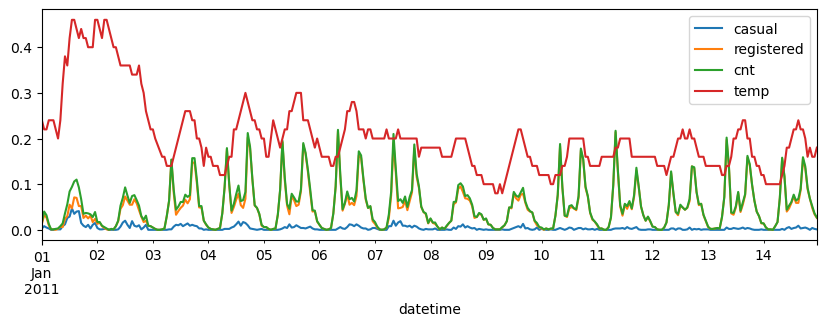

In [14]:
df_2weeks = df[:24 * 7 * 2]
df_2weeks[['casual', 'registered', 'cnt', 'temp']].plot(figsize=(10, 3))

<Axes: xlabel='datetime'>

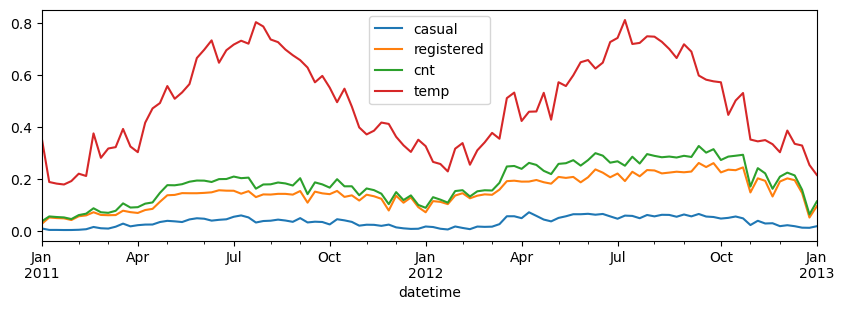

In [15]:
df_daily = df.resample('W').mean()
df_daily[['casual', 'registered', 'cnt', 'temp']].plot(figsize=(10, 3))

# Wskaźniki bazowe

In [16]:
df_1 = df.copy()

df_1['pred_daily'] = df_1['cnt'].shift(24)
mae_daily = (df_1['cnt'] - df_1['pred_daily']).abs().mean() * 1000

df_1['pred_weekly'] = df_1['cnt'].shift(24 * 7)
mae_weekly = (df_1['cnt'] - df_1['pred_weekly']).abs().mean() * 1000

In [17]:
(mae_daily, mae_weekly)

(np.float64(63.79497716894976), np.float64(52.42506906077348))

In [18]:
import pickle

In [19]:
with open('mae_baseline.pkl', 'wb') as f:
    pickle.dump((mae_daily, mae_weekly), f)

# Predykcja przy pomocy sieci gęstej

In [20]:
cnt_train = df['cnt']['2011-01-01 00:00':'2012-06-30 23:00']
cnt_valid = df['cnt']['2012-07-01 00:00':]

In [21]:
seq_len = 1 * 24
train_ds = tf.keras.utils.timeseries_dataset_from_array(
    cnt_train.to_numpy(),
    targets=cnt_train[seq_len:],
    sequence_length=seq_len,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_ds = tf.keras.utils.timeseries_dataset_from_array(
    cnt_valid.to_numpy(),
    targets=cnt_valid[seq_len:],
    sequence_length=seq_len,
    batch_size=32
)

2025-06-12 22:51:54.685503: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M4 Pro
2025-06-12 22:51:54.685525: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 48.00 GB
2025-06-12 22:51:54.685532: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 18.00 GB
I0000 00:00:1749761514.685547 2183253 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1749761514.685565 2183253 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [22]:
model = tf.keras.Sequential([
    tf.keras.Input(shape=(seq_len,)),
    tf.keras.layers.Dense(1)
])

In [23]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

In [24]:
history_dense = model.fit(train_ds, epochs=20, validation_data=valid_ds, verbose=1)

Epoch 1/20


2025-06-12 22:51:54.892105: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0107 - mae: 0.1067 - val_loss: 0.0069 - val_mae: 0.0781
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0032 - mae: 0.0540 - val_loss: 0.0056 - val_mae: 0.0729
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0027 - mae: 0.0500 - val_loss: 0.0050 - val_mae: 0.0693
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0025 - mae: 0.0479 - val_loss: 0.0046 - val_mae: 0.0664
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0023 - mae: 0.0461 - val_loss: 0.0044 - val_mae: 0.0641
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0022 - mae: 0.0449 - val_loss: 0.0042 - val_mae: 0.0622
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0021 - mae: 0.0436 - val_loss: 0.0040 - val_mae: 0.0614
Epoch 8/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0021 - mae: 0.0428 - val_loss: 0.0039 - val_mae: 0.0598
Epoch 9/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.0020 

In [25]:
model.save('model_linear.keras')

In [26]:
mae_linear = model.evaluate(valid_ds)[1] * 1000

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0036 - mae: 0.0584


In [27]:
mae_linear

55.45664578676224

In [28]:
with open('mae_linear.pkl', 'wb') as f:
    pickle.dump((mae_linear,), f)

# Prosta sieć rekurencyjna

In [29]:
model_rnn1 = tf.keras.Sequential([
    tf.keras.Input(shape=[None, 1]),
    tf.keras.layers.LSTM(1)
])

In [30]:
model_rnn1.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

In [31]:
history_rnn1 = model_rnn1.fit(train_ds, epochs=20, validation_data=valid_ds, verbose=1)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0524 - mae: 0.2361 - val_loss: 0.0571 - val_mae: 0.2549
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0209 - mae: 0.1548 - val_loss: 0.0345 - val_mae: 0.2007
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0146 - mae: 0.1364 - val_loss: 0.0246 - val_mae: 0.1678
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0112 - mae: 0.1207 - val_loss: 0.0188 - val_mae: 0.1446
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0090 - mae: 0.1085 - val_loss: 0.0154 - val_mae: 0.1294
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0077 - mae: 0.0996 - val_loss: 0.0135 - val_mae: 0.1211
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0069 - mae: 0.0930 - val_loss: 0.0124 - val_mae: 0.1164
Epoch 8/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0063 - mae: 0.0885 - val_loss: 0.0117 - val_mae: 0.1132
Epoch 9/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - lo

In [32]:
model_rnn1.save('model_rnn1.keras')

In [33]:
mae_rnn1 = model_rnn1.evaluate(valid_ds)[1] * 1000

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0081 - mae: 0.0894


In [34]:
mae_rnn1

86.26826852560043

In [35]:
with open('mae_rnn1.pkl', 'wb') as f:
    pickle.dump((mae_rnn1,), f)

In [36]:
model_rnn32 = tf.keras.Sequential([
    tf.keras.Input(shape=[None, 1]),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])

In [37]:
model_rnn32.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

In [38]:
history_rnn32 = model_rnn32.fit(train_ds, epochs=20, validation_data=valid_ds, verbose=1)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0097 - mae: 0.1014 - val_loss: 0.0061 - val_mae: 0.0696
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0028 - mae: 0.0495 - val_loss: 0.0047 - val_mae: 0.0618
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0023 - mae: 0.0445 - val_loss: 0.0047 - val_mae: 0.0700
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0023 - mae: 0.0445 - val_loss: 0.0043 - val_mae: 0.0641
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0023 - mae: 0.0449 - val_loss: 0.0043 - val_mae: 0.0650
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0022 - mae: 0.0435 - val_loss: 0.0045 - val_mae: 0.0618
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0021 - mae: 0.0426 - val_loss: 0.0040 - val_mae: 0.0630
Epoch 8/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0020 - mae: 0.0418 - val_loss: 0.0036 - val_mae: 0.0563
Epoch 9/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - lo

In [39]:
model_rnn32.save('model_rnn32.keras')

In [40]:
mae_rnn32 = model_rnn32.evaluate(valid_ds)[1] * 1000

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0025 - mae: 0.0470


In [41]:
mae_rnn32

45.62835022807121

In [42]:
with open('mae_rnn32.pkl', 'wb') as f:
    pickle.dump((mae_rnn32,), f)

# Głęboka RNN

In [43]:
model_rnn_deep = tf.keras.Sequential([
    tf.keras.Input(shape=[None, 1]),
    tf.keras.layers.LSTM(512, return_sequences=True),
    tf.keras.layers.LSTM(512, return_sequences=True),
    tf.keras.layers.LSTM(512),
    tf.keras.layers.Dense(1)
])

In [44]:
model_rnn_deep.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

In [45]:
history_rnn_deep = model_rnn_deep.fit(train_ds, epochs=20, validation_data=valid_ds, verbose=1)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0139 - mae: 0.1075 - val_loss: 0.0050 - val_mae: 0.0680
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0024 - mae: 0.0461 - val_loss: 0.0045 - val_mae: 0.0601
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0018 - mae: 0.0400 - val_loss: 0.0043 - val_mae: 0.0593
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0018 - mae: 0.0401 - val_loss: 0.0035 - val_mae: 0.0560
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0015 - mae: 0.0368 - val_loss: 0.0026 - val_mae: 0.0488
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0013 - mae: 0.0341 - val_loss: 0.0032 - val_mae: 0.0497
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0011 - mae: 0.0318 - val_loss: 0.0030 - val_mae: 0.0487
Epoch 8/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 9.8545e-04 - mae: 0.0301 - val_loss: 0.0027 - val_mae: 0.0471
Epoch 9/20
410/410 ━━━━━━━━━━━━━━━━━

In [46]:
model_rnn_deep.save('model_rnn_deep.keras')

In [47]:
mae_rnn_deep = model_rnn_deep.evaluate(valid_ds)[1] * 1000

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0015 - mae: 0.0358


In [48]:
mae_rnn_deep

34.37251225113869

In [49]:
with open('mae_rnn_deep.pkl', 'wb') as f:
    pickle.dump((mae_rnn_deep,), f)

# Model wielowymiarowy

In [50]:
feature_cols = ['cnt', 'weathersit', 'atemp', 'workingday']
target_col = 'cnt'

features_df = df[feature_cols]
target_series = df[target_col]

train_features = features_df.loc[:'2012-06-30']
valid_features = features_df.loc['2012-07-01':]
train_targets = target_series.loc[:'2012-06-30']
valid_targets = target_series.loc['2012-07-01':]

In [51]:
train_ds_mv = tf.keras.utils.timeseries_dataset_from_array(
    train_features.to_numpy(),
    targets=train_targets[seq_len:],
    sequence_length=seq_len,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_ds_mv = tf.keras.utils.timeseries_dataset_from_array(
    valid_features.to_numpy(),
    targets=valid_targets[seq_len:],
    sequence_length=seq_len,
    batch_size=32
)

In [52]:
model_rnn_mv = tf.keras.Sequential([
    tf.keras.Input(shape=[None, 4]),
    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dense(1)
])

In [53]:
model_rnn_mv.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

In [54]:
history_rnn_mv = model_rnn_mv.fit(train_ds_mv, epochs=20, validation_data=valid_ds_mv, verbose=1)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.0098 - mae: 0.1036 - val_loss: 0.0082 - val_mae: 0.0827
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0033 - mae: 0.0548 - val_loss: 0.0056 - val_mae: 0.0656
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0026 - mae: 0.0479 - val_loss: 0.0052 - val_mae: 0.0627
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0024 - mae: 0.0466 - val_loss: 0.0042 - val_mae: 0.0616
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0019 - mae: 0.0429 - val_loss: 0.0031 - val_mae: 0.0559
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0015 - mae: 0.0381 - val_loss: 0.0022 - val_mae: 0.0443
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 0.0011 - mae: 0.0320 - val_loss: 0.0021 - val_mae: 0.0427
Epoch 8/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 9.5912e-04 - mae: 0.0297 - val_loss: 0.0019 - val_mae: 0.0404
Epoch 9/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step

In [55]:
model_rnn_mv.save('model_rnn_mv.keras')

In [56]:
mae_rnn_mv = model_rnn_mv.evaluate(valid_ds_mv)[1] * 1000

138/138 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0020 - mae: 0.0400


In [57]:
mae_rnn_mv

37.53954917192459

In [58]:
with open('mae_rnn_mv.pkl', 'wb') as f:
    pickle.dump((mae_rnn_mv,), f)

# Model custom

In [59]:
target_col = 'cnt'

target_series = df[target_col]

train_features = df.loc[:'2012-06-30']
valid_features = df.loc['2012-07-01':]
train_targets = target_series.loc[:'2012-06-30']
valid_targets = target_series.loc['2012-07-01':]

In [66]:
train_ds_custom = tf.keras.utils.timeseries_dataset_from_array(
    train_features.to_numpy(),
    targets=train_targets[seq_len:],
    sequence_length=seq_len,
    batch_size=32,
    shuffle=True,
    seed=42
)
valid_ds_custom = tf.keras.utils.timeseries_dataset_from_array(
    valid_features.to_numpy(),
    targets=valid_targets[seq_len:],
    sequence_length=seq_len,
    batch_size=32
)

In [67]:
len(df.columns)

11

In [68]:
model_rnn_custom = tf.keras.Sequential([
    tf.keras.Input(shape=[None, len(df.columns)]),
    tf.keras.layers.LSTM(512, return_sequences=True),
    tf.keras.layers.LSTM(512, return_sequences=True),
    tf.keras.layers.LSTM(512),
    tf.keras.layers.Dense(1)
])

In [69]:
model_rnn_custom.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss=tf.keras.losses.Huber(),
    metrics=['mae']
)

In [71]:
history_rnn_custom = model_rnn_custom.fit(train_ds_custom, epochs=20, validation_data=valid_ds_custom, verbose=1)

Epoch 1/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 11s 24ms/step - loss: 0.0462 - mae: 0.1526 - val_loss: 0.0061 - val_mae: 0.0804
Epoch 2/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 0.0023 - mae: 0.0474 - val_loss: 0.0032 - val_mae: 0.0556
Epoch 3/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0013 - mae: 0.0355 - val_loss: 0.0031 - val_mae: 0.0546
Epoch 4/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - loss: 0.0012 - mae: 0.0327 - val_loss: 0.0016 - val_mae: 0.0390
Epoch 5/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 0.0010 - mae: 0.0317 - val_loss: 0.0016 - val_mae: 0.0374
Epoch 6/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - loss: 9.0642e-04 - mae: 0.0292 - val_loss: 0.0024 - val_mae: 0.0444
Epoch 7/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 8.6802e-04 - mae: 0.0285 - val_loss: 0.0018 - val_mae: 0.0387
Epoch 8/20
410/410 ━━━━━━━━━━━━━━━━━━━━ 10s 24ms/step - loss: 7.6061e-04 - mae: 0.0263 - val_loss: 0.0017 - val_mae: 0.0384
Epoch 9/20
410/410 ━━━━━━━━━━

In [72]:
mae_rnn_custom = model_rnn_custom.evaluate(valid_ds_custom)[1] * 1000

138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0012 - mae: 0.0337


In [73]:
mae_rnn_custom

32.47707709670067

In [75]:
df['cnt'] *= 1000

In [76]:
df

,casual,registered,cnt,temp,atemp,hum,windspeed,holiday,weekday,workingday,weathersit
datetime,,,,,,,,,,,
2011-01-01 00:00:00,0.003,0.013,16.0,0.24,0.2879,0.81,0.0000,0,6,0,0.25
2011-01-01 01:00:00,0.008,0.032,40.0,0.22,0.2727,0.80,0.0000,0,6,0,0.25
2011-01-01 02:00:00,0.005,0.027,32.0,0.22,0.2727,0.80,0.0000,0,6,0,0.25
2011-01-01 03:00:00,0.003,0.010,13.0,0.24,0.2879,0.75,0.0000,0,6,0,0.25
2011-01-01 04:00:00,0.000,0.001,1.0,0.24,0.2879,0.75,0.0000,0,6,0,0.25
...,...,...,...,...,...,...,...,...,...,...,...
2012-12-31 19:00:00,0.011,0.108,119.0,0.26,0.2576,0.60,0.1642,0,1,1,0.50
2012-12-31 20:00:00,0.008,0.081,89.0,0.26,0.2576,0.60,0.1642,0,1,1,0.50
2012-12-31 21:00:00,0.007,0.083,90.0,0.26,0.2576,0.60,0.1642,0,1,1,0.25
